> ⚠️ **Superseded draft.** The canonical EDA is `01_eda_2.ipynb`, which covers the same checks plus the label-source analysis and right-censoring. This notebook is kept for the record only. Its figures use the same filenames, so run `01_eda_2` last if you regenerate figures.

# 01 — Exploratory Data Analysis: ccMixter Remix Graph

**Thesis:** Predicting Remixability in Online Music Communities
**This notebook:** understand the raw built dataset before any preprocessing or
modelling. It reads the immutable crawler output and writes **nothing** except
figures. Every cleaning decision is *justified here* and *applied in
`02_preprocess`* — never mutate the raw files.

**How to use this notebook.** The code cells run the analysis; the
markdown cells marked **✍️ Interpretation** are for *you* to fill in. Do not
skip them — in the viva, the documented reasoning is what counts, not the
numbers. Where I already know what the data shows (from an earlier pass), I've
left a prompt rather than the answer, so the conclusion is yours to state and
defend.

**Reproducibility note:** treat the findings as a checklist to *at minimum*
reproduce, not a ceiling. Run your own checks freely; if something you find
contradicts a prompt below, trust your analysis and the data.

## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from pathlib import Path

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)
plt.rcParams["figure.figsize"] = (9, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

# Point this at your data/processed folder. Raw files are READ-ONLY here.
DATA = Path("data/processed")
FIGDIR = Path("figures"); FIGDIR.mkdir(exist_ok=True)

nodes = pd.read_csv(DATA / "nodes.csv")
edges = pd.read_csv(DATA / "edges.csv")
removed = pd.read_csv(DATA / "edges_removed.csv")

print("nodes:", nodes.shape)
print("edges:", edges.shape)
print("removed edges:", removed.shape)

nodes: (51486, 21)
edges: (62300, 8)
removed edges: (684, 9)


## 1. First look — shape, columns, types

Before anything else: how big is it, what columns exist, and are the dtypes what
we expect? A column that pandas read as `object` when it should be numeric is a
classic silent bug.

In [2]:
display(nodes.head())
print(nodes.dtypes)
print("\nunique tracks:", nodes["upload_id"].nunique(), "of", len(nodes), "rows")
print("duplicate upload_id:", int(nodes["upload_id"].duplicated().sum()))

,upload_id,user_name,user_id,user_real_name,name,date_iso,date_unix,year,license,license_url,score,num_scores,num_playlists,thumbs_up,num_files,n_remixes,n_sources,usertags,systags,page_url,has_meta
0,41,wired,NaN,WIRED Magazine CD,Wired Loop Example,2004-10-28T01:20:00+00:00,1098926400,NaN,Noncommercial Sampling Plus,http://creativecommons.org/licenses/nc-samplin...,400.0,3.0,NaN,1,6,0,5,"bass,guitar,kawai,saxophone,vocals","nc_sampling_plus,audio,mp3,44k,stereo,VBR,arch...",https://ccmixter.org/files/wired/41,False
1,42,wired,NaN,WIRED Magazine CD,Wired Loops 01 (sampling+),2004-10-28T01:20:00+00:00,1098926400,NaN,Sampling Plus,http://creativecommons.org/licenses/sampling+/...,NaN,1.0,NaN,1,1,1,0,"female_vocals,jazz,saxophone","sampling_plus,archive,zip",https://ccmixter.org/files/wired/42,False
2,43,wired,NaN,WIRED Magazine CD,Wired Loops 02 (sampling+),2004-10-28T01:20:00+00:00,1098926400,NaN,Sampling Plus,http://creativecommons.org/licenses/sampling+/...,NaN,NaN,NaN,1,1,2,0,saxophone,"sampling_plus,archive,zip",https://ccmixter.org/files/wired/43,False
3,44,wired,NaN,WIRED Magazine CD,Wired Loops 03 (sampling+),2004-10-28T01:20:00+00:00,1098926400,NaN,Sampling Plus,http://creativecommons.org/licenses/sampling+/...,NaN,NaN,NaN,1,1,3,0,"12_string,bandeon,bass,female_vocals,guitar,sa...","sampling_plus,archive,zip",https://ccmixter.org/files/wired/44,False
4,45,wired,NaN,WIRED Magazine CD,Wired Loops 04 (sampling+),2004-10-28T01:20:00+00:00,1098926400,NaN,Sampling Plus,http://creativecommons.org/licenses/sampling+/...,NaN,NaN,NaN,1,1,1,0,"brass,brazil,calmantes,canastra,independent,me...","sampling_plus,archive,zip",https://ccmixter.org/files/wired/45,False


upload_id           int64
user_name             str
user_id           float64
user_real_name        str
name                  str
date_iso              str
date_unix           int64
year              float64
license               str
license_url           str
score             float64
num_scores        float64
num_playlists     float64
thumbs_up           int64
num_files           int64
n_remixes           int64
n_sources           int64
usertags              str
systags               str
page_url              str
has_meta             bool
dtype: object

unique tracks: 51486 of 51486 rows
duplicate upload_id: 0


## 2. Missingness — which columns are usable?

This is the single most decision-relevant table in the notebook. A column that is
mostly null cannot be a feature, no matter how appealing it sounds.

,percent_null
num_playlists,100.0
user_id,100.0
year,100.0
score,90.1
num_scores,8.8
usertags,5.5
page_url,0.0
systags,0.0
n_sources,0.0
n_remixes,0.0


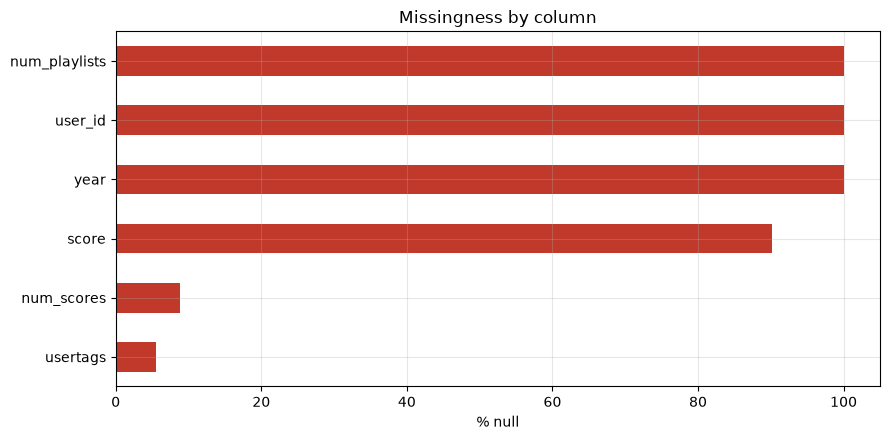

In [3]:
miss = (nodes.isna().mean() * 100).round(1).sort_values(ascending=False)
miss.name = "percent_null"
display(miss.to_frame())

ax = miss[miss > 0].plot.barh(color="#c0392b")
ax.set_xlabel("% null"); ax.set_title("Missingness by column")
ax.invert_yaxis(); plt.tight_layout()
plt.savefig(FIGDIR / "missingness.png", dpi=120); plt.show()

**Interpretation.**
- **Fully empty:** `user_id`, `year` and `num_playlists` are 100 % null. The dataview used by the crawler does not expose them. Dropping them loses nothing: author identity is fully carried by `user_name`, and the date by `date_iso` / `date_unix`.
- **Constant:** `thumbs_up` (always 1) and `has_meta` (always False) carry no information.
- **Mostly empty:** `score` is 90.1 % null and is dropped (see §4).
- **Partly empty and kept:** `num_scores` (8.8 % null; see §4) and `usertags` (5.5 % null, meaning the uploader added no tags; encoded as an empty tag set with a `has_usertags` flag).

## 3. Temporal coverage — the backbone of RQ2

RQ2 predicts using only information available *at post time*, so the timestamp is
load-bearing. Check: did every date parse? What's the real span? Any impossible
(future) dates? What does posting activity look like over time?

parse failures: 0
min: 2004-10-28 01:20:00+00:00 | max: 2026-07-20 21:30:00+00:00
in the future: 0


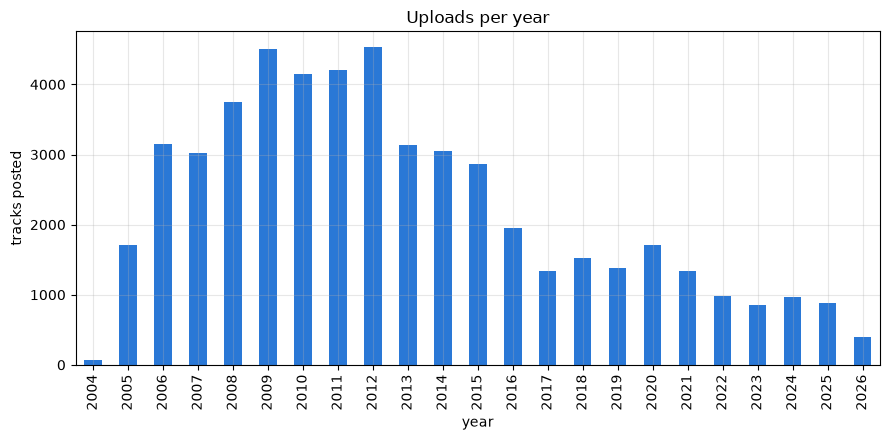

date_iso
2004      67
2005    1716
2006    3152
2007    3029
2008    3749
2009    4501
2010    4142
2011    4210
2012    4531
2013    3142
2014    3053
2015    2868
2016    1958
2017    1335
2018    1517
2019    1381
2020    1714
2021    1333
2022     987
2023     858
2024     961
2025     885
2026     397
Name: count, dtype: int64

In [4]:
d = pd.to_datetime(nodes["date_iso"], errors="coerce", utc=True)
print("parse failures:", int(d.isna().sum()))
print("min:", d.min(), "| max:", d.max())
print("in the future:", int((d > pd.Timestamp.now(tz='UTC')).sum()))

by_year = d.dt.year.value_counts().sort_index()
ax = by_year.plot.bar(color="#2a78d6")
ax.set_xlabel("year"); ax.set_ylabel("tracks posted"); ax.set_title("Uploads per year")
plt.tight_layout(); plt.savefig(FIGDIR / "uploads_per_year.png", dpi=120); plt.show()
display(by_year)

**Interpretation.** Every date parses, and none lies in the future. The data span 28 Oct 2004 to 20 Jul 2026.

- **Growth:** activity rose quickly from 2005 (1,716 uploads) and peaked in 2009–2012 (4,100–4,500 uploads per year).
- **Decline:** uploads fell steadily after 2012, to about 1,300–1,700 a year in 2017–2021 and under 1,000 a year from 2022. 2026 is a partial year (397 tracks up to the crawl date).

The thin recent years matter for the design:
- The temporal test set (2022 onwards) is small, 3,330 tracks.
- Recent tracks have had little time to be remixed. This right-censoring is quantified in §7.

## 4. Engagement columns — what's real, what's noise?

Several columns *look* like popularity signals. Verify each before trusting it.
The key question for `score`: is it present exactly when a track has ratings, or
is it sparse and unexplained?

In [5]:
for col in ["score", "num_scores", "num_playlists", "thumbs_up", "num_files"]:
    s = pd.to_numeric(nodes[col], errors="coerce")
    print(f"{col:14} null%={nodes[col].isna().mean()*100:5.1f}  "
          f"min={s.min()}  max={s.max()}  mean={s.mean():.2f}  nunique={s.nunique()}")

print("\n-- Is `score` present only for a subset of rated tracks? --")
sc = pd.to_numeric(nodes["score"], errors="coerce")
ns = pd.to_numeric(nodes["num_scores"], errors="coerce")
print("tracks with num_scores>0 :", int((ns > 0).sum()))
print("tracks with score present:", int(sc.notna().sum()))
print("score present AND rated  :", int((sc.notna() & (ns > 0)).sum()))

score          null%= 90.1  min=100.0  max=500.0  mean=430.90  nunique=116
num_scores     null%=  8.8  min=1.0  max=251.0  mean=9.51  nunique=94
num_playlists  null%=100.0  min=nan  max=nan  mean=nan  nunique=0
thumbs_up      null%=  0.0  min=1  max=1  mean=1.00  nunique=1
num_files      null%=  0.0  min=1  max=99  mean=1.87  nunique=46

-- Is `score` present only for a subset of rated tracks? --
tracks with num_scores>0 : 46980
tracks with score present: 5113
score present AND rated  : 3884


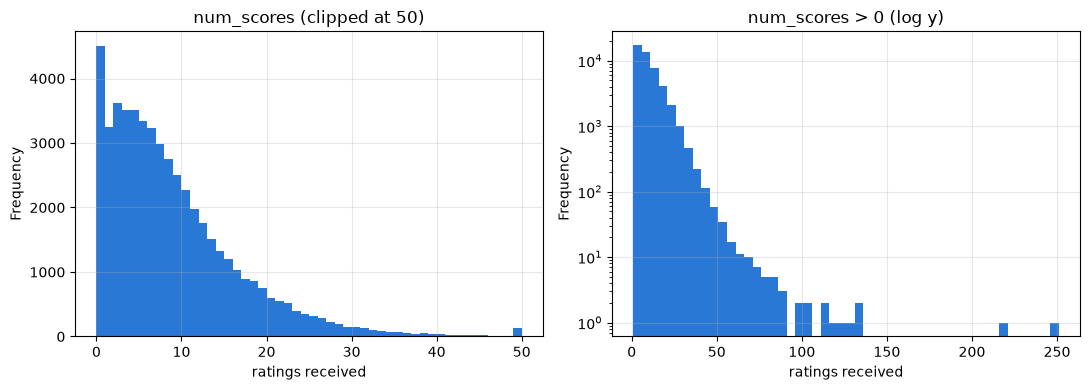

In [6]:
# num_scores is the candidate engagement signal — look at its distribution
ns = pd.to_numeric(nodes["num_scores"], errors="coerce")
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ns.fillna(0).clip(upper=50).plot.hist(bins=50, ax=axes[0], color="#2a78d6")
axes[0].set_title("num_scores (clipped at 50)"); axes[0].set_xlabel("ratings received")
ns[ns > 0].plot.hist(bins=50, ax=axes[1], color="#2a78d6", log=True)
axes[1].set_title("num_scores > 0 (log y)"); axes[1].set_xlabel("ratings received")
plt.tight_layout(); plt.savefig(FIGDIR / "num_scores_dist.png", dpi=120); plt.show()

**Interpretation.**
- **`num_scores` is kept** as the only usable engagement count. Whenever it is present, its minimum is 1, and the key is missing when a track has no ratings. A null therefore means zero, and `02` fills it with 0 and records a flag.
  - It is a snapshot of *today's* value, so it is a popularity confound. It is **not** used as a prediction feature.
- **`score` is dropped.** It is 90.1 % null, takes values 100–500, looks like a sparse rating rather than a count, and is present on only 5,113 tracks.
- **`thumbs_up` is dropped** (constant 1), and so is **`num_playlists`** (always empty).
- **`num_files`** (mean 1.87, max 99) is complete and fixed at upload, so it is a valid feature.

## 5. The outcome variable — distribution and class balance

Edges point **parent → child** ("parent was remixed into child"). So a track
**was remixed** iff it has **out-edges**; it **is a remix** iff it has in-edges.
`n_remixes` in the node table is the crawl's own count — cross-check it against
the graph you actually built.

In [7]:
# build the directed graph from the (local) edges
local = edges[edges["edge_type"] == "local"]
G = nx.DiGraph()
G.add_nodes_from(nodes["upload_id"].astype(int))
G.add_edges_from(local[["parent_id", "child_id"]].astype(int).itertuples(index=False, name=None))

out_deg = pd.Series(dict(G.out_degree()))          # remixes RECEIVED
is_remixed = (out_deg > 0)

print("tracks:", len(out_deg))
print("remixed at least once:", int(is_remixed.sum()),
      f"({is_remixed.mean()*100:.1f}%)")

# cross-check against the crawl's own count column
crawl_count = nodes.set_index("upload_id")["n_remixes"].reindex(out_deg.index).fillna(0)
agree = (crawl_count.gt(0) == is_remixed)
print("agreement between graph out-degree>0 and n_remixes>0:",
      f"{agree.mean()*100:.2f}%")

tracks: 51486
remixed at least once: 18766 (36.4%)
agreement between graph out-degree>0 and n_remixes>0: 97.31%


0        32720
1         8922
2         3820
3-5       3786
6-10      1390
11-25      679
26+        169
Name: count, dtype: int64

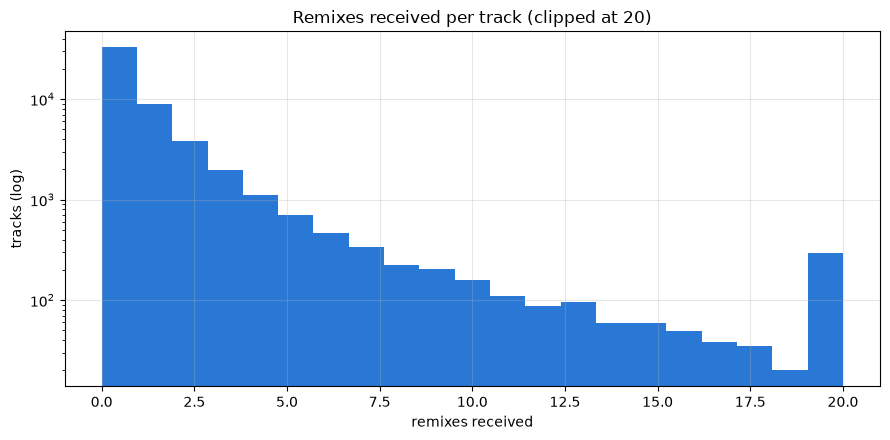

In [8]:
# distribution of remixes received
buckets = pd.cut(out_deg, [-1,0,1,2,5,10,25,10_000],
                 labels=["0","1","2","3-5","6-10","11-25","26+"])
display(buckets.value_counts().reindex(["0","1","2","3-5","6-10","11-25","26+"]))

ax = out_deg.clip(upper=20).plot.hist(bins=21, color="#2a78d6", log=True)
ax.set_xlabel("remixes received"); ax.set_ylabel("tracks (log)")
ax.set_title("Remixes received per track (clipped at 20)")
plt.tight_layout(); plt.savefig(FIGDIR / "remixes_received.png", dpi=120); plt.show()

**Interpretation.**

**Label rule.** The outcome is taken from `edges.csv` (the track has at least one local child), never from the `n_remixes` counter. Every graph-positive has a real, dated child, and the time-based features and horizon labels in `03` need that date.

**Where the two sources disagree.** The counter reports 1,387 more remixed tracks (2.7 %) than the graph. The disagreement runs in one direction only.
- **Pool edges:** 14 of these tracks involve pool/off-site links.
- **No surviving child:** 1,373 have a counter value but no child in the crawl.
  - Only 41 of these are explained by the 684 time-inverted edges removed during cleaning.
  - The rest are most plausibly stale counters or deleted children. Almost all (1,295) involve a single remix.
- **Scale of the noise:** this label noise is bounded at 2.7 % and one-directional. Excluding these tracks leaves test AUC unchanged (0.842 → 0.843; see `04`).

**Local vs "all".** The "ALL" count (19,002) differs from the local count (18,766) only because of 236 tracks whose IDs collide with pool-item IDs. Pool items are never tracks, so a local+pool outcome is identical to the local outcome, and it is not used.

**Base rate and class balance.** 36.4 % of tracks were ever remixed, and 15.7 % spawned a second-generation remix. The classes are reasonably balanced, so no resampling is needed.

**Heavy tail.** Reuse is heavily skewed: 63.6 % of tracks are never remixed, while 169 tracks were remixed 26 or more times (maximum 493). This matches the concentration of reuse reported by Cheliotis & Yew and Calefato et al.

## 6. Graph structure — degree, cascade depth, components

The remix graph is a certified DAG (cycles were removed upstream; see §7). That
lets us measure **cascade depth** = how many remix generations deep a track sits.
This tests the claim that remix cascades are shallow.

is DAG: True


0     20258
1     23824
2      4744
3      1547
4       666
5       248
6       112
7        45
8        29
9        10
10        3
Name: count, dtype: int64

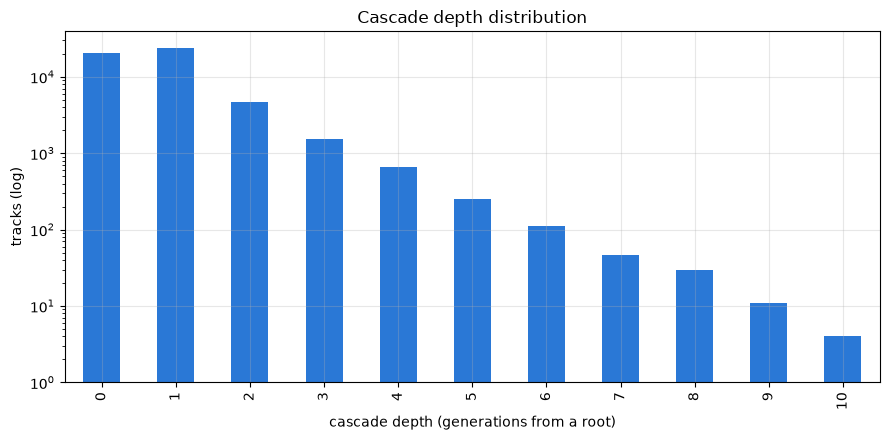

depth 1 share: 76.3%
depth <=2 share: 91.5%
max depth: 10


In [9]:
print("is DAG:", nx.is_directed_acyclic_graph(G))

# cascade depth via longest path from a root (topological pass)
depth = {}
for node in nx.topological_sort(G):
    preds = list(G.predecessors(node))
    depth[node] = 0 if not preds else 1 + max(depth[p] for p in preds)
depth = pd.Series(depth)

dist = depth.value_counts().sort_index()
display(dist)
ax = dist.plot.bar(color="#2a78d6", log=True)
ax.set_xlabel("cascade depth (generations from a root)")
ax.set_ylabel("tracks (log)"); ax.set_title("Cascade depth distribution")
plt.tight_layout(); plt.savefig(FIGDIR / "cascade_depth.png", dpi=120); plt.show()

# among tracks that ARE in a lineage (depth>=1), what share is depth 1 or 2?
in_lineage = depth[depth >= 1]
print("depth 1 share:", f"{(in_lineage==1).mean()*100:.1f}%")
print("depth <=2 share:", f"{(in_lineage<=2).mean()*100:.1f}%")
print("max depth:", int(depth.max()))

In [10]:
# weakly-connected components: is there one giant remix network or many islands?
comp_sizes = pd.Series(sorted((len(c) for c in nx.weakly_connected_components(G)),
                              reverse=True))
print("components:", len(comp_sizes))
print("largest component:", int(comp_sizes.iloc[0]),
      f"({comp_sizes.iloc[0]/len(nodes)*100:.1f}% of tracks)")
print("singletons (size 1):", int((comp_sizes == 1).sum()))
display(comp_sizes.head(10).to_frame("component_size"))

components: 9797
largest component: 39280 (76.3% of tracks)
singletons (size 1): 8385


,component_size
0,39280
1,15
2,13
3,12
4,12
5,12
6,11
7,11
8,10
9,9


**Interpretation.**

**Integrity.** The cleaned local graph is a DAG, and our depth distribution matches `summary.json` exactly.

**Cascade depth.** Of the 31,228 tracks that are themselves remixes:
- 76.3 % sit one generation from an original,
- 91.5 % sit within two generations,
- the tail is thin and reaches depth 10 (3 tracks).

So the claim that remix cascades are "1–2 levels deep" is correct as a description of the typical case, not as a hard limit. The 20,258 tracks at depth 0 include both originals and unconnected uploads.

**Components.** There are 9,797 weakly connected components, but one giant component holds 39,280 tracks (76.3 % of all tracks). Most of the remaining components are singletons (8,385). The community therefore forms one large, interconnected reuse network rather than many isolated clusters.

The two 76.3 % figures are a numerical coincidence and measure different things.

## 7. Removed edges — audit the cleaning decision

684 edges were dropped upstream because the "parent" was posted *after* the
"child" (time-inverted → impossible in a real lineage). This section verifies
that removal was justified rather than taking it on faith. In the viva you may be
asked *why* you dropped data — this is your evidence.

In [11]:
print("removed reasons:", removed["_removed_reason"].value_counts().to_dict())

r = removed.copy()
r["gap_days"] = (r["parent_date_unix"] - r["child_date_unix"]) / 86400
print("\nall removed have parent newer than child:",
      bool((r["parent_date_unix"] > r["child_date_unix"]).all()))
print("time gap (days) — how far backwards:")
display(r["gap_days"].describe())

# same-artist check: are these self-remixes / same-session uploads?
pu = r["parent_user"] if "parent_user" in r else pd.Series(index=r.index, dtype=object)
print("\nExample removed edges (look for same artist, tiny gaps):")
display(r[["parent_id","child_id","parent_user","gap_days"]].head(12))

removed reasons: {'time_inverted': 684}

all removed have parent newer than child: True
time gap (days) — how far backwards:


count     684.000000
mean      453.031040
std       449.211626
min         0.002083
25%        29.357465
50%       391.414583
75%       867.640451
max      2300.952083
Name: gap_days, dtype: float64


Example removed edges (look for same artist, tiny gaps):


,parent_id,child_id,parent_user,gap_days
0,68890,68085,JohnJones,161.002083
1,62395,62367,speck,4.582639
2,52204,52154,Haskel,1.293056
3,49777,49734,solos_to_use,5.000000
4,49776,49734,solos_to_use,4.992361
5,49775,49734,solos_to_use,4.982639
6,49774,49734,solos_to_use,4.977778
7,48272,48168,Haskel,5.313194
8,47993,47975,snowflake,1.763889
9,47984,47975,SackJo22,0.753472


**Interpretation.** All 684 removed edges point backwards in time: the "parent" was posted after the "child". Such a link is impossible in a real lineage, and these edges were the only source of cycles.

The gaps are not mainly same-session uploads:
- 9 % of removed edges have a gap under 1 day,
- 25 % under 30 days,
- 51 % more than a year (median 391 days, maximum 2,301).

Only 1.9 % of removed edges link tracks by the same artist. The table above shows the smallest gaps only, so it is not representative. The label printed above the table ("same artist, tiny gaps") overstates this pattern.

The edges were **dropped rather than reversed**. That makes no claim about the true direction, which is the conservative choice. They are 1.1 % of all edges and explain only 41 of the 1,387 counter disagreements in §5.

## 8. Edge set — types, sources, integrity

In [12]:
print("edge_type:", edges["edge_type"].value_counts().to_dict())
print("source   :", edges["source"].value_counts().to_dict())
print("duplicate (parent,child):", int(edges.duplicated(["parent_id","child_id"]).sum()))
print("self-loops:", int((edges["parent_id"]==edges["child_id"]).sum()))

node_ids = set(nodes["upload_id"])
print("child not in nodes:", int((~edges["child_id"].isin(node_ids)).sum()))
print("parent not in nodes (pool/off-site parents):",
      int((~edges["parent_id"].isin(node_ids)).sum()))

edge_type: {'local': 59186, 'pool': 3114}
source   : {'embedded': 38876, 'query': 23424}
duplicate (parent,child): 0
self-loops: 0
child not in nodes: 0
parent not in nodes (pool/off-site parents): 2578


**Interpretation.** Edge integrity holds: there are no duplicate pairs, no self-loops, and no dangling child references.

**Edge types.** Of 62,300 edges, 59,186 are *local* (track → track, used for all analysis) and 3,114 are *pool* (off-site sample → track).

**Why the parent counts differ.** Only 2,578 edges have a parent outside the node table, even though there are 3,114 pool edges. The other 536 pool edges carry pool-item IDs that numerically coincide with track IDs. Pool and track IDs are separate numbering schemes, so pool edges must never be joined to tracks by ID.

**Crawl sources.** 38,876 edges came from source lists embedded in track records, and 23,424 from the separate query pass. These are two independent routes to the same links, and a bidirectional check on a 200-track sample found full agreement.

## 9. EDA summary — decisions carried into `02_preprocess`

- **Columns dropped:**
  - `user_id`, `year` and `num_playlists` (100 % null);
  - `thumbs_up` and `has_meta` (constant);
  - `score` (90 % null, undocumented).
- **Columns kept:** identifiers, dates, licence, `num_files`, `n_sources`, `usertags`, `systags`, `num_scores` (diagnostic only) and `n_remixes` (audit only).
- **Engagement signal:** `num_scores`, with nulls filled as 0 (a missing key means no ratings) and a flag recorded. It is a snapshot value and is **not** used as a feature.
- **Outcome:** the primary outcome is `is_remixed` (at least one local child), with a base rate of 36.4 %. The secondary outcome is `spawned_further_remix`, with a base rate of 15.7 %.
- **Label source:** the local edge graph, never `n_remixes`. They disagree for 1,387 tracks (2.7 %), always in one direction; see §5.
- **Edge definition:** local edges only. A local+pool variant adds no information for outcomes (pool items are not tracks) and is affected by ID collisions.
- **Horizon and cutoff:** 365 days (with 180 and 730 as alternates); cutoff 2022-01-01.
- **Author concentration:** 49 accounts (the top 1 %) produced 40.9 % of all tracks; this is quantified in `04`.
- **Data-quality caveats:**
  - 2.7 % of labels are one-directionally noisy;
  - 684 time-inverted edges were dropped;
  - recent years are sparse and right-censored;
  - the data are licensed CC BY-NC.

Next: **`02_preprocess`** applies these decisions, then **`03_features_split`** builds the temporal split and the leakage-safe features.